Import libraries  
Define dataset directory paths and structures

In [81]:
import os
import random
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np

random.seed(42)

new_dataset = "new_dataset"
white_dataset = "/kagglehub/datasets/gpiosenka/coffee-bean-dataset-resized-224-x-224/versions/1"
black_dataset = "/CoffeBeans.v6i.multiclass"

splits = ["train", "val", "test"]
black_splits = ["train", "valid", "test"]
classes = ["Green", "Light", "Medium", "Dark"]

Define functions for summarizing datasets including new dataset, white-background dataset (dataset_summary) and black-background dataset (black_dataset_summary)

In [72]:
def dataset_summary(root, splits=splits):
    rows = []

    for split in splits:
        for cls in classes:
            path = os.path.join(root, split, cls)
            if os.path.exists(path):
                rows.append([split, cls, len(os.listdir(path))])

    df = pd.DataFrame(rows, columns=["Split", "Class", "Count"])
    pivot = df.pivot(index="Class", columns="Split", values="Count").fillna(0)

    pivot["Total"] = pivot.sum(axis=1)
    pivot["Percentage (%)"] = (pivot["Total"] / pivot["Total"].sum() * 100).round(2)

    return pivot


def black_dataset_summary(root):
    rows = []

    for split in black_splits:
        folder = os.path.join(root, split)
        if not os.path.exists(folder):
            continue

        files = os.listdir(folder)

        for cls in classes:
            count = sum(f.lower().startswith(cls.lower()) for f in files)
            rows.append([split, cls, count])

    df = pd.DataFrame(rows, columns=["Split", "Class", "Count"])
    pivot = df.pivot(index="Class", columns="Split", values="Count").fillna(0)

    pivot["Total"] = pivot.sum(axis=1)
    pivot["Percentage (%)"] = (pivot["Total"] / pivot["Total"].sum() * 100).round(2)

    return pivot

Inspect 2 source datasets

In [73]:
print("White dataset:")
display(dataset_summary(white_dataset))

print("\nBlack dataset:")
display(black_dataset_summary(black_dataset))

White dataset:


Split,test,train,Total,Percentage (%)
Class,,,,
Dark,100,300,400,25.0
Green,100,300,400,25.0
Light,100,300,400,25.0
Medium,100,300,400,25.0



Black dataset:


Split,test,train,valid,Total,Percentage (%)
Class,,,,,
Dark,29,711,29,769,24.76
Green,33,714,28,775,24.95
Light,28,732,28,788,25.37
Medium,30,711,33,774,24.92


Create a directory structure for the new dataset:  
`new_dataset/`  
`├── train/`  
`│ ├── Dark/`  
`│ ├── Green/`  
`│ ├── Light/`  
`│ └── Medium/`  
`│`  
`├── val/`  
`│ ├── Dark/`  
`│ ├── Green/`  
`│ ├── Light/`  
`│ └── Medium/`  
`│`  
`└── test/`  
`├── Dark/`  
`├── Green/`  
`├── Light/`  
`└── Medium/`  

In [74]:
for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(new_dataset, split, cls), exist_ok=True)

Define functions for collecting all images from both datasets

In [75]:
def collect_images_white(cls):
    paths = []
    for split in ["train", "test"]:
        folder = os.path.join(white_dataset, split, cls)
        if os.path.exists(folder):
            paths += [os.path.join(folder, f) for f in os.listdir(folder)]
    return paths

def collect_images_black(cls):
    paths = []
    for split in black_splits:
        folder = os.path.join(black_dataset, split)
        if os.path.exists(folder):
            paths += [
                os.path.join(folder, f)
                for f in os.listdir(folder)
                if f.lower().startswith(cls.lower())
            ]
    return paths

Split the collected images into 70/15/15 for train/val/test

In [76]:
def split_dataset(images):
    n = len(images)
    return images[:int(0.7*n)], images[int(0.7*n):int(0.85*n)], images[int(0.85*n):]

Rename the images and copy them into corresponding directory in the new dataset

In [ ]:
def copy_images(images, split, cls):
    dst = os.path.join(new_dataset, split, cls)
    start = len(os.listdir(dst))

    for i, path in enumerate(images):
        ext = os.path.splitext(path)[1]
        new_name = f"{cls}_{start+i}{ext}"
        shutil.copy(path, os.path.join(dst, new_name))

Merge 2 datasets using the created functions

In [77]:
for collector in [collect_images_white, collect_images_black]:
    for cls in classes:
        imgs = collector(cls)
        random.shuffle(imgs)

        train, val, test = split_dataset(imgs)

        copy_images(train, "train", cls)
        copy_images(val, "val", cls)
        copy_images(test, "test", cls)

Summary of the merged dataset

In [82]:
summary = dataset_summary(new_dataset)
display(summary)

Split,test,train,val,Total,Percentage (%)
Class,,,,,
Dark,176,818,175,1169,24.84
Green,177,822,176,1175,24.97
Light,179,831,178,1188,25.24
Medium,177,821,176,1174,24.95


Visualize the image distribution of the new dataset

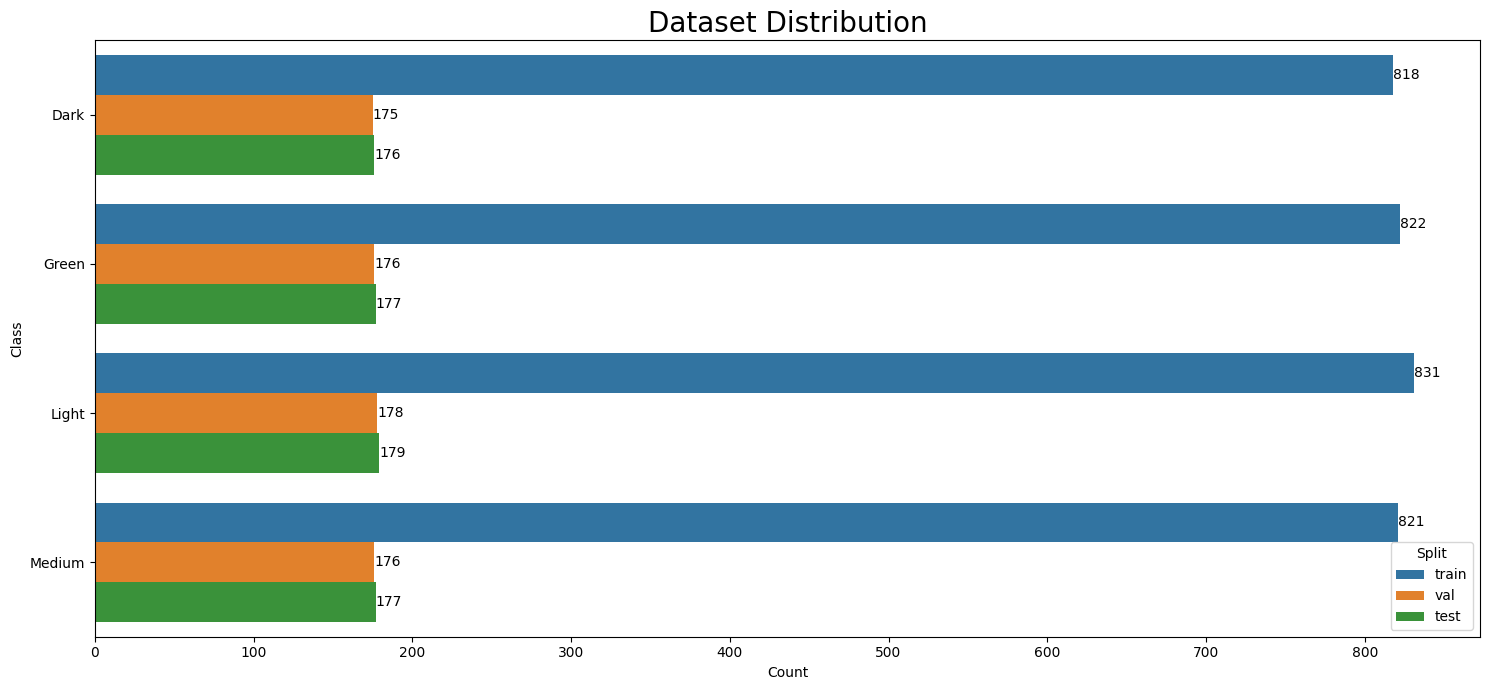

In [83]:
plot_df = summary.drop(index="Total", errors="ignore").reset_index()

plot_df = plot_df.melt(
    id_vars="Class",
    value_vars=["train", "val", "test"],
    var_name="Split",
    value_name="Count"
)

plt.figure(figsize=(15, 7))

ax = sns.barplot(data=plot_df, x="Count", y="Class", hue="Split")

plt.title("Dataset Distribution", fontsize=20)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

Display sample images for each class from the new dataset

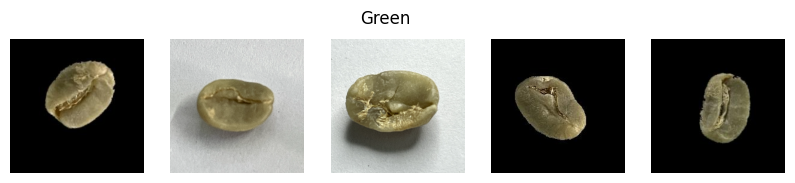

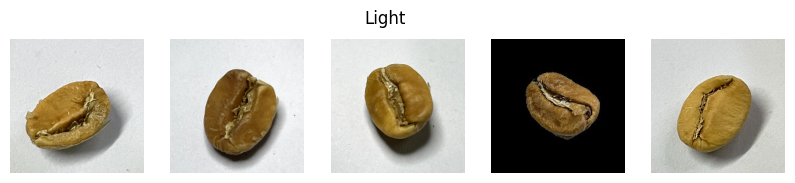

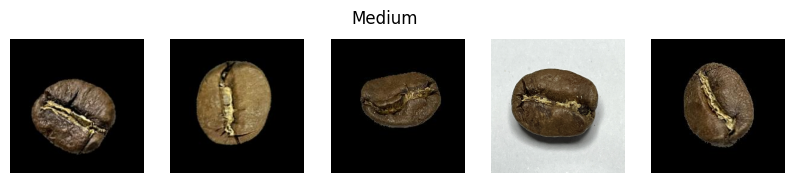

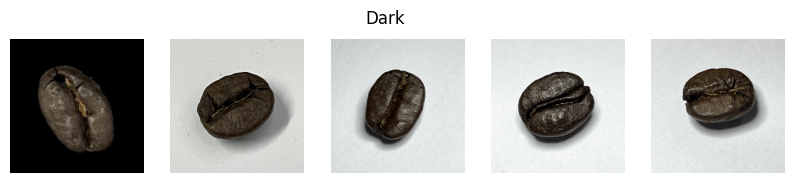

In [84]:
def show_samples(root, cls, n=5):
    folder = os.path.join(root, "train", cls)
    imgs = random.sample(os.listdir(folder), n)

    plt.figure(figsize=(10,2))
    for i, img_name in enumerate(imgs):
        img = Image.open(os.path.join(folder, img_name))
        plt.subplot(1,n,i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(cls)
    plt.show()

for c in classes:
    show_samples(new_dataset, c)